<a href="https://colab.research.google.com/github/Jaellynda/Sentinel_Dispatch/blob/main/Sentinel_Dispatch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Default title text
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)

def generate_dispatch_data(n_rows=7000):
    # 1. Basic Categorical Features
    incident_types = ['Medical', 'Structure Fire', 'Traffic Accident', 'Wellness Check', 'False Alarm']
    unit_types = ['Ambulance', 'Engine', 'Ladder', 'Rescue Squad', 'Chief']
    priorities = [1, 2, 3] # 1 is highest priority
    weather_conditions = ['Clear', 'Rain', 'Snow', 'Fog', 'Storm']

    data = {
        'Incident_ID': range(1000, 1000 + n_rows),
        'Incident_Type': np.random.choice(incident_types, n_rows, p=[0.5, 0.1, 0.2, 0.1, 0.1]),
        'Unit_Type': np.random.choice(unit_types, n_rows),
        'Priority': np.random.choice(priorities, n_rows, p=[0.3, 0.5, 0.2]),
        'Weather_Index': np.random.choice(weather_conditions, n_rows, p=[0.6, 0.2, 0.05, 0.1, 0.05]),
        'Hour_of_Day': np.random.randint(0, 24, n_rows)
    }

    df = pd.DataFrame(data)

    # 2. Define the Target Variable (TurnoutTime_Seconds) with Logic
    # Base turnout time is 60 seconds
    turnout_time = 60.0 + np.random.normal(0, 10, n_rows)

    # Apply Logic/Patterns
    for i in range(n_rows):
        # Priority Logic: Higher priority (1) is faster
        if df.loc[i, 'Priority'] == 1: turnout_time[i] -= 15
        if df.loc[i, 'Priority'] == 3: turnout_time[i] += 20

        # Weather Logic: Storms and Snow cause delays
        if df.loc[i, 'Weather_Index'] in ['Storm', 'Snow']:
            turnout_time[i] += np.random.uniform(20, 45)

        # Rush Hour Logic (7-9 AM and 4-6 PM)
        if 7 <= df.loc[i, 'Hour_of_Day'] <= 9 or 16 <= df.loc[i, 'Hour_of_Day'] <= 18:
            turnout_time[i] += np.random.uniform(15, 30)

        # Unit Logic: Engines/Ladders take longer to prep than Ambulances
        if df.loc[i, 'Unit_Type'] in ['Engine', 'Ladder']:
            turnout_time[i] += 10

    # Ensure no negative times and round to integers
    df['TurnoutTime_Seconds'] = np.maximum(turnout_time, 30).astype(int)

    return df

# Generate and Save
sentinel_data = generate_dispatch_data(5000)
sentinel_data.to_csv('sentinel_dispatch_data.csv', index=False)

print("Success! 'sentinel_dispatch_data.csv' created with 5,000 rows.")
print(sentinel_data.head())

Success! 'sentinel_dispatch_data.csv' created with 5,000 rows.
   Incident_ID     Incident_Type     Unit_Type  Priority Weather_Index  \
0         1000           Medical        Ladder         2          Rain   
1         1001       False Alarm        Ladder         1         Clear   
2         1002  Traffic Accident  Rescue Squad         2         Clear   
3         1003    Structure Fire        Ladder         2         Clear   
4         1004           Medical         Chief         1         Clear   

   Hour_of_Day  TurnoutTime_Seconds  
0            6                   61  
1           23                   52  
2           17                   75  
3            9                   97  
4           14                   49  


In [2]:
#The Preprocessing Pipeline
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Load the data you generated
df = pd.read_csv('sentinel_dispatch_data.csv')

# 2. Cyclical Feature Engineering for 'Hour_of_Day'
# This helps the DNN understand time loops
df['hr_sin'] = np.sin(2 * np.pi * df['Hour_of_Day'] / 24)
df['hr_cos'] = np.cos(2 * np.pi * df['Hour_of_Day'] / 24)

# 3. Define Features and Target
X = df.drop(['Incident_ID', 'TurnoutTime_Seconds', 'Hour_of_Day'], axis=1)
y = df['TurnoutTime_Seconds']

# 4. Create the Preprocessing Transformer
# We One-Hot Encode categories and Scale numerical inputs
categorical_features = ['Incident_Type', 'Unit_Type', 'Weather_Index']
numerical_features = ['Priority', 'hr_sin', 'hr_cos']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# 5. Split and Transform
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original shape: {X_train.shape}")
print(f"Processed shape (after encoding): {X_train_processed.shape}")
print("Data is now ready for the DNN!")

Original shape: (4000, 6)
Processed shape (after encoding): (4000, 18)
Data is now ready for the DNN!


In [3]:
#Building the DNN
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define the Architecture
model = models.Sequential([
    # Input layer (input_shape should match your processed X_train columns)
    layers.Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),

    # Hidden layers
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),

    # Output layer: 1 unit for TurnoutTime_Seconds (no activation for regression)
    layers.Dense(1)
])

# 2. Compile the Model
# We use 'adam' optimizer and 'mse' (Mean Squared Error) to penalize large errors
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. Train the Model
print("Starting training...")
history = model.fit(
    X_train_processed, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 4. Evaluate
test_loss, test_mae = model.evaluate(X_test_processed, y_test)
print(f"\nModel Mean Absolute Error on Test Set: {test_mae:.2f} seconds")

Starting training...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4322.8076 - mae: 60.9535 - val_loss: 972.4314 - val_mae: 25.4205
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 343.4067 - mae: 14.2857 - val_loss: 238.6892 - val_mae: 12.1474
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 217.6656 - mae: 11.7165 - val_loss: 192.6544 - val_mae: 11.1276
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 187.3315 - mae: 10.9624 - val_loss: 173.5460 - val_mae: 10.5767
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 175.6714 - mae: 10.6002 - val_loss: 167.1174 - val_mae: 10.4098
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 171.7165 - mae: 10.5009 - val_loss: 161.5899 - val_mae: 10.1608
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 168.0849 - mae: 10.3608 - val_loss: 159.5684 - val_mae: 10.1246
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 165.0237 - mae: 10.2681 - val_loss: 156.7192 - val_mae: 10.0301
Epoch 9/50
100/100

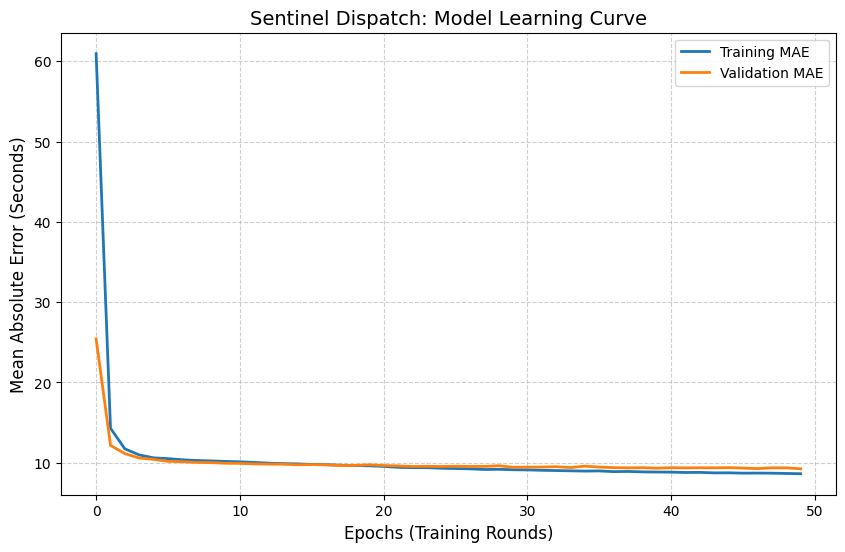

In [4]:
#Visualizing the "Sentinel" Brain

import matplotlib.pyplot as plt

# Plotting the Training and Validation MAE
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='Training MAE', color='#1f77b4', lw=2)
plt.plot(history.history['val_mae'], label='Validation MAE', color='#ff7f0e', lw=2)

plt.title('Sentinel Dispatch: Model Learning Curve', fontsize=14)
plt.xlabel('Epochs (Training Rounds)', fontsize=12)
plt.ylabel('Mean Absolute Error (Seconds)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Save the plot so you can upload it to GitHub
plt.savefig('learning_curve.png')
plt.show()

In [6]:
#The "Sentinel" Predictor

def sentinel_predict(incident_type, priority, unit_type, weather, hour):
    """
    Takes raw emergency details and returns a predicted turnout time.
    """
    # 1. Create a mini-dataframe for the new incident
    new_data = pd.DataFrame({
        'Incident_Type': [incident_type],
        'Priority': [priority],
        'Unit_Type': [unit_type],
        'Weather_Index': [weather],
        'hr_sin': [np.sin(2 * np.pi * hour / 24)],
        'hr_cos': [np.cos(2 * np.pi * hour / 24)]
    })

    # 2. Transform the data using the fitted preprocessor
    # Note: We only use .transform(), NOT .fit_transform()
    processed_input = preprocessor.transform(new_data)

    # 3. Predict using the DNN
    prediction = model.predict(processed_input, verbose=0)

    return round(float(prediction[0][0]), 2)

# --- TEST SCENARIO ---
# Scenario: A Priority 1 Medical call during a Storm at 5 PM (Rush Hour)
estimate = sentinel_predict('Medical', 1, 'Ambulance', 'Storm', 17)

print(f"SENTINEL DISPATCH REPORT")
print(f"Predicted Turnout Time: {estimate} seconds")

SENTINEL DISPATCH REPORT
Predicted Turnout Time: 93.17 seconds
